## Integration by interpolation

In [1]:
from itertools import pairwise
import matplotlib.pyplot as plt
import numpy as np
import sympy as smp
from scipy.integrate import simpson, quad, trapezoid
from sympy.functions.special.bsplines import interpolating_spline
from sympy.polys.specialpolys import interpolating_poly

plt.style.use('dark_background')

In [2]:
x = smp.symbols('x', real = True, positive = True) # x symbolic

a, b = 1, 12 # range
X = [j for j in range(a, b + 1, 1)] # x points
Y = [12.5, 13.1, 11.7, 9.3, 8.3, 6.3, 5.3, 4.6, 5.1, 6.4, 10.3, 13.9] # y points

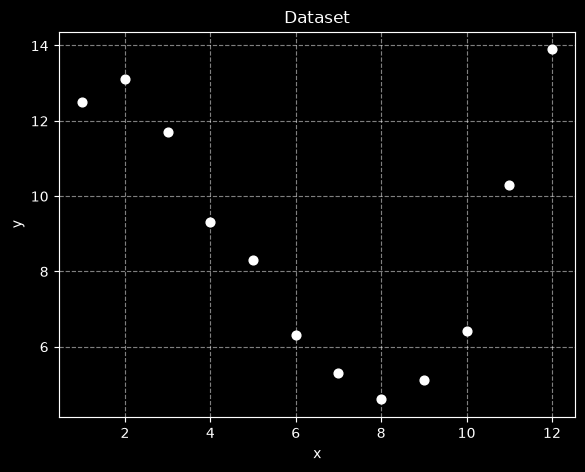

In [ ]:
# Plot points
plt.title('Dataset')
plt.scatter(X, Y, color = 'white')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

In [4]:
pol = interpolating_poly( # Symbolic interpolation
    n = b,
    x = x,
    X = X,
    Y = Y
    )

pol

-3.13151354818021e-7*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 7)*(x - 6)*(x - 5)*(x - 4)*(x - 3)*(x - 2) + 3.61000881834215e-6*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 7)*(x - 6)*(x - 5)*(x - 4)*(x - 3)*(x - 1) - 1.61210317460317e-5*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 7)*(x - 6)*(x - 5)*(x - 4)*(x - 2)*(x - 1) + 3.84424603174603e-5*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 7)*(x - 6)*(x - 5)*(x - 3)*(x - 2)*(x - 1) - 6.86177248677249e-5*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 7)*(x - 6)*(x - 4)*(x - 3)*(x - 2)*(x - 1) + 7.29166666666667e-5*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 7)*(x - 5)*(x - 4)*(x - 3)*(x - 2)*(x - 1) - 6.13425925925926e-5*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 8)*(x - 6)*(x - 5)*(x - 4)*(x - 3)*(x - 2)*(x - 1) + 3.80291005291005e-5*(x - 12)*(x - 11)*(x - 10)*(x - 9)*(x - 7)*(x - 6)*(x - 5)*(x - 4)*(x - 3)*(x - 2)*(x - 1) - 2.10813492063492e-5*(x - 12)*(x - 11)*(x - 10)*(x - 8)*(x - 7)*(x - 6)*(x - 5)*(x - 4)*(x - 3)*

In [5]:
pol = smp.lambdify(x, pol, 'numpy') # NumPyfying

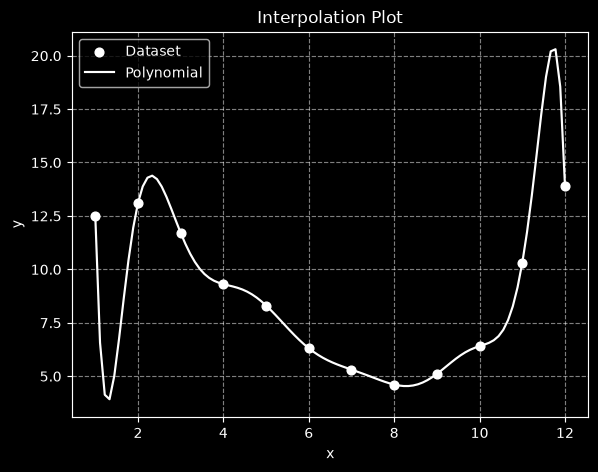

In [6]:
# Plot the polynomial
XX = np.linspace(a, b, 100)
plt.title('Interpolation Plot')
plt.scatter(X, Y, color = 'white', label = 'Dataset')
plt.plot(XX, pol(XX), color = 'white', label = 'Polynomial')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend(loc = 'best')
plt.show()

In [ ]:
sp = [interpolating_spline( # Local interpolation: linear, quadratic and cubic
    d = j,
    x = x,
    X = X,
    Y = Y
) for j in range(1, 3 + 1, 1)]

sp1, sp2, sp3 = sp

In [8]:
sp1 # Linear spline

Piecewise((0.6*x + 11.9, (x >= 1) & (x <= 2)), (15.9 - 1.4*x, (x >= 2) & (x <= 3)), (18.9 - 2.4*x, (x >= 3) & (x <= 4)), (13.3 - 1.0*x, (x >= 4) & (x <= 5)), (18.3 - 2.0*x, (x >= 5) & (x <= 6)), (12.3 - 1.0*x, (x >= 6) & (x <= 7)), (10.2 - 0.7*x, (x >= 7) & (x <= 8)), (0.5*x + 0.600000000000001, (x >= 8) & (x <= 9)), (1.3*x - 6.6, (x >= 9) & (x <= 10)), (3.9*x - 32.6, (x >= 10) & (x <= 11)), (3.6*x - 29.3, (x >= 11) & (x <= 12)))

In [9]:
sp2 # Quadratic spline

Piecewise((-1.04346917564042*x**2 + 3.73040752692124*x + 9.81306164871917, (x >= 1) & (x <= 5/2)), (-0.695715770517082*x**2 + 1.99164050130457*x + 11.98652043074, (x >= 5/2) & (x <= 7/2)), (1.21776379874291*x**2 - 11.4027164835154*x + 35.4266451541749, (x >= 7/2) & (x <= 9/2)), (-1.01086702194039*x**2 + 8.65496090263433*x - 9.70312896466193, (x >= 9/2) & (x <= 11/2)), (0.847438332899432*x**2 - 11.7863980006037*x + 46.5106080192427, (x >= 11/2) & (x <= 13/2)), (-0.0737629754562037*x**2 + 0.18921900801956*x + 7.58985274121707, (x >= 13/2) & (x <= 15/2)), (0.795139519837783*x**2 - 12.8443184213902*x + 56.4656181015039, (x >= 15/2) & (x <= 17/2)), (0.102925856429504*x**2 - 1.07668614344951*x + 6.45318092025568, (x >= 17/2) & (x <= 19/2)), (1.78730534158521*x**2 - 33.0798963614078*x + 158.468429455558, (x >= 19/2) & (x <= 21/2)), (-0.426757905940742*x**2 + 13.4154318366371*x - 85.6320435841782, (x >= 21/2) & (x <= 12)))

In [10]:
sp3 # Cubic spline

Piecewise((0.0297763801537418*x**3 - 1.17865828092245*x**2 + 3.92754018169117*x + 9.72134171907755, (x >= 1) & (x <= 3)), (0.851118099231303*x**3 - 8.57073375262051*x**2 + 26.1037665967853*x - 12.4548846960166, (x >= 3) & (x <= 4)), (-1.03424877707896*x**3 + 14.0536687631027*x**2 - 64.3938434661075*x + 108.20859538784, (x >= 4) & (x <= 5)), (0.885877009084557*x**3 - 14.7482180293501*x**2 + 79.6155904961565*x - 131.8071278826, (x >= 5) & (x <= 6)), (-0.50925925925926*x**3 + 10.3642348008386*x**2 - 71.0591264849757*x + 169.542306079665, (x >= 6) & (x <= 7)), (0.451160027952481*x**3 - 9.80457023060798*x**2 + 70.1225087351504*x - 159.881509433963, (x >= 7) & (x <= 8)), (-0.395380852550664*x**3 + 10.5124109014675*x**2 - 92.4133403214535*x + 273.547421383648, (x >= 8) & (x <= 9)), (0.730363382250174*x**3 - 19.8826834381551*x**2 + 181.14250873515*x - 547.120125786163, (x >= 9) & (x <= 10)), (-0.726072676450036*x**3 + 23.8103983228512*x**2 - 255.788308874913*x + 909.315932914047, (x >= 10) & (

In [11]:
# Going numerically
sp1 = smp.lambdify(x, sp1, 'numpy')
sp2 = smp.lambdify(x, sp2, 'numpy')
sp3 = smp.lambdify(x, sp3, 'numpy')

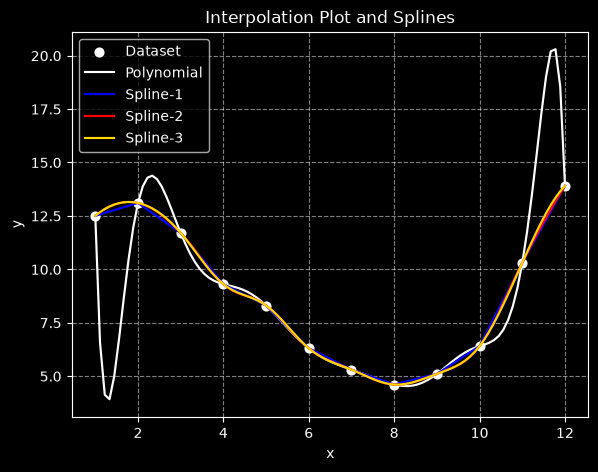

In [12]:
# Plot all curves
XX = np.linspace(a, b, 100)
plt.title('Interpolation Plot and Splines')
plt.scatter(X, Y, color = 'white', label = 'Dataset')
plt.plot(XX, pol(XX), color = 'white', label = 'Polynomial')
plt.plot(XX, sp1(XX), color = 'blue', label = 'Spline-1')
plt.plot(XX, sp2(XX), color = 'red', label = 'Spline-2')
plt.plot(XX, sp3(XX), color = 'gold', label = 'Spline-3')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.legend(loc = 'best')
plt.show()

In [ ]:
# Computing the integral using Simpson's rule
Y2 = [v for pair in pairwise(Y) for v in (pair[0], sum(pair) / 2)] + [Y[-1]]

I_data = simpson(
    y = Y,
    dx = 1.0,
    x = None
)

I_data2 = simpson(
    y = Y2,
    dx = 0.5,
    x = None
)

err = 16.0 / 15.0 * abs(I_data2 - I_data) # Richardson extrapolation
I_data, err

(np.float64(92.92500000000001), np.float64(0.7199999999999818))

In [14]:
I_pol = quad(pol, a, b) # Integral of the polynomial
I_pol

(92.64768302767675, 1.0285959087550007e-12)

In [15]:
I_sp1 = quad(sp1, a, b) # Integral of linear spline. Doesn't work. Use trapezoid instead
I_sp1

<positron-console-cell-15>:1: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


(93.6000020879513, 0.0009395991392098148)

In [16]:
I_sp1 = trapezoid( # Stable
    y = Y,
    dx = 1.0,
    x = None
)

I_sp1

np.float64(93.6)

In [17]:
I_sp2 = quad(sp2, a, b) # Integral of quadratic spline
I_sp2

(93.4725189352721, 7.958976055988387e-07)

In [18]:
I_sp3 = quad(sp3, a, b) # Integral of cubic spline
I_sp3

(93.57180816128627, 7.474290213801882e-07)